The probability density function $f_\theta(x)$ is defined as:

$
f_\theta(x) =
\begin{cases}
\theta^2 & \text{if } -1 \le x < 0 \\
1 - \theta^2 & \text{if } 0 \le x \le 1 \\
0 & \text{otherwise}
\end{cases}
$


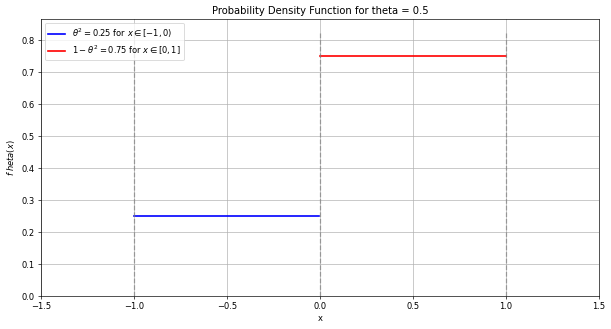

For theta = 0.5:
  Value in [-1, 0): 0.2500
  Value in [0, 1]: 0.7500
The integral over [-1, 1] is: 1


In [ ]:
''' Probability Density Function for theta '''

#### $\hat{\theta}_{MLE}$

Let $X_1, \dots, X_n$ be i.i.d. samples from this distribution, where we define $a$ the number of samples in the interval $[-1, 0)$ (i.e., $X_i < 0$), $b$: the number of samples in the interval $[0, 1]$ (i.e., $X_i \ge 0$), $n = a + b$: the total number of samples.

The probabilities of a single sample falling into each interval are:
- $P(X_i < 0) = \int_{-1}^{0} \theta^2 \, dx = \theta^2 [x]_{-1}^{0} = \theta^2 (0 - (-1)) = \theta^2$; $P(X_i \ge 0) = \int_{0}^{1} (1 - \theta^2) \, dx = (1 - \theta^2) [x]_{0}^{1} = (1 - \theta^2) (1 - 0) = 1 - \theta^2$.

The likelihood function $L(\theta)$ is the probability of observing $a$ samples in the first interval and $b$ samples in the second, which follows a binomial distribution for the count $a$ (or $b$):
- $L(\theta) = \binom{n}{a} (P(X < 0))^a (P(X \ge 0))^b = \binom{n}{a} (\theta^2)^a (1 - \theta^2)^b$

For the MLE, we maximize the log-likelihood function:
- $\log L(\theta) = \log \binom{n}{a} + \log((\theta^2)^a) + \log((1 - \theta^2)^b) = \log \binom{n}{a} + 2a \log(\theta) + b \log(1 - \theta^2)$

Next, we take the derivative of the log-likelihood with respect to $\theta$ and set it to zero to find the critical point:
$\frac{d}{d\theta} \log L(\theta) = \frac{2a}{\theta} + b \frac{-2\theta}{1 - \theta^2} = 0$.
Set the derivative to zero:
$\frac{2a}{\theta} = \frac{2b\theta}{1 - \theta^2}$.
Multiply both sides by $\theta(1 - \theta^2)$:
$2a(1 - \theta^2) = 2b\theta^2$, thus
$a = (a+b)\theta^2$. Since $n = a+b$:
$a = n\theta^2$.

Solving for $\theta^2$: $\theta^2 = \frac{a}{n}$

- finally, solving for $\theta$ (since $\theta \in (0, 1)$, we take the positive square root):
$\hat{\theta}_{MLE} = \sqrt{\frac{a}{n}}$

#### Asymptotic Properties of $\hat{\theta}_{MLE}$

The $\hat{\theta}_{MLE}$ derived from the counts $a$ and $b$ has desirable asymptotic properties under certain regularity conditions. Specifically, $\hat{\theta}_{MLE}$ is **asymptotically normal**, meaning that as the sample size $n \to \infty$, the distribution of $\hat{\theta}_{MLE}$ approaches a normal distribution.
We found that $\hat{\theta}_{MLE} = \sqrt{a/n}$. Let $p = \theta^2$ be the true probability of $X < 0$. Then $a/n$ is the sample proportion estimating $p$. We know that $a \sim \text{Binomial}(n, p)$, so $a/n$ is an estimator for $p$. By the Central Limit Theorem,
$\sqrt{n} \left( \frac{a}{n} - p \right) \xrightarrow{d} N(0, p(1-p))$. To find the asymptotic distribution of $\hat{\theta}_{MLE} = g(a/n)$ where $g(p) = \sqrt{p}$, we use the **Delta Method**. The derivative of $g(p)$ is $g'(p) = \frac{1}{2\sqrt{p}}$.
Therefore, by the Delta Method:
$\sqrt{n} (\hat{\theta}_{MLE} - \theta) \xrightarrow{d} N\left(0, [g'(p)]^2 p(1-p)\right)$.
Substituting $g'(p) = \frac{1}{2\sqrt{p}}$ and $p = \theta^2$:
$[g'(p)]^2 p(1-p) = \left(\frac{1}{2\sqrt{\theta^2}}\right)^2 \theta^2(1-\theta^2) = \frac{1}{4\theta^2} \theta^2(1-\theta^2) = \frac{1-\theta^2}{4}$.

The asymptotic distribution is:
$\sqrt{n} (\hat{\theta}_{MLE} - \theta) \xrightarrow{d} N\left(0, \frac{1-\theta^2}{4}\right)$.
This implies that for large $n$, $\hat{\theta}_{MLE} \approx N\left(\theta, \frac{1-\theta^2}{4n}\right)$.
**The asymptotic variance of $\hat{\theta}_{MLE}$ is $\frac{1-\theta^2}{4n}$**.
We can estimate this by plugging in $\hat{\theta}_{MLE}$ for $\theta$.

In [ ]:
# Using the theta_val from earlier for simulation
theta_true = theta_val # Use 0.5 from the kernel state

# Number of samples (reusing n_samples from Gaussian simulation, which is 1000)
n_samples = 1000 # Explicitly define n_samples here to avoid NameError
n_samples_custom = n_samples

# Simulate samples from the custom PDF
np.random.seed(43) # for reproducibility for this simulation
random_uniform_choices = np.random.rand(n_samples_custom)

simulated_samples = np.zeros(n_samples_custom)

# P(X < 0) = theta_true^2
prob_negative = theta_true**2

# Generate samples based on the probabilities
simulated_samples[random_uniform_choices < prob_negative] = np.random.uniform(-1, 0, size=np.sum(random_uniform_choices < prob_negative))
simulated_samples[random_uniform_choices >= prob_negative] = np.random.uniform(0, 1, size=np.sum(random_uniform_choices >= prob_negative))

# Count 'a' and 'b'
a = np.sum(simulated_samples < 0)
b = np.sum(simulated_samples >= 0)
n = a + b

# Calculate theta_mle
theta_mle = np.sqrt(a / n)

Simulated 'a' (negative samples): 233
Simulated 'b' (non-negative samples): 767
Total samples 'n': 1000
Calculated theta_mle: 0.4827


In [ ]:
# Calculate the estimated asymptotic variance of theta_mle
# Using the formula: (1 - theta_mle^2) / (4 * n_samples)

estimated_asymptotic_variance_theta_mle = (1 - theta_mle**2) / (4 * n_samples)
estimated_asymptotic_std_error_theta_mle = np.sqrt(estimated_asymptotic_variance_theta_mle)

Estimated MLE for theta (θ_hat): 0.4827
Estimated asymptotic variance of θ_hat: 0.000192
Estimated asymptotic standard error of θ_hat: 0.013847


#### Wald Test for $H_0: X$ $\sim$ $\text{Unif}(-1,1)$

We define the following null and alternative hypotheses:
- $H_0: X \sim \text{Unif}(-1,1) \iff \theta = \frac{1}{\sqrt{2}}$, $H_1: X \not\sim \text{Unif}(-1,1) \iff \theta \ne \frac{1}{\sqrt{2}}$

The Wald test statistic for a single parameter is given by:
$T_{\text{Wald}} = \frac{(\hat{\theta}_{MLE} - \theta_0)^2}{\text{Var}(\hat{\theta}_{MLE})}$, where $\theta_0 = \frac{1}{\sqrt{2}}$ under the null hypothesis, and the asymptotic variance of $\hat{\theta}_{MLE}$ is $\frac{1 - \theta_0^2}{4n}$ (using $\theta_0$ under the null).
Asymptotically, $T_{\text{Wald}} \sim \chi^2_1$ under $H_0$. We define the Wald test with asymptotic level $\alpha$ as:
$\psi_{\text{Wald}} = \mathbf{1}(T_{\text{Wald}} > q_{\alpha})$ where $q_{\alpha}$ is the $(1-\alpha)$-quantile of the $\chi^2_1$ distribution.

In [ ]:
from scipy.stats import chi2

# Define theta_0 under the null hypothesis
theta_0 = 1 / np.sqrt(2)

# Calculate the estimated asymptotic variance under the null hypothesis
# Var(theta_mle) = (1 - theta_0^2) / (4 * n)
# Use 'n' from the previous simulation (which is n_samples)
estimated_asymptotic_variance_under_H0 = (1 - theta_0**2) / (4 * n_samples)

# Calculate the Wald test statistic
T_Wald = (theta_mle - theta_0)**2 / estimated_asymptotic_variance_under_H0

# Calculate the p-value
p_value_wald = 1 - chi2.cdf(T_Wald, df=1)

if p_value_wald < 0.05:
    print("At a 0.05 significance level, we reject the null hypothesis. The data does not appear to be Uniform(-1,1).")
else:
    print("At a 0.05 significance level, we fail to reject the null hypothesis. The data appears consistent with Uniform(-1,1).")

Null hypothesis (H0): theta = 0.7071
Observed MLE for theta (theta_mle): 0.4827
Wald Test Statistic (T_Wald): 402.8646
P-value for Wald Test: 0.0000
At a 0.05 significance level, we reject the null hypothesis. The data does not appear to be Uniform(-1,1).


We performed a Wald test to evaluate the null hypothesis that the data comes from a Uniform distribution on $(-1,1)$, which is equivalent to testing $H_0: \theta = \frac{1}{\sqrt{2}}$ against the alternative $H_1: \theta \ne \frac{1}{\sqrt{2}}$.

**Hypotheses:**
- $H_0: X \sim \text{Unif}(-1,1) \iff \theta = \frac{1}{\sqrt{2}}$ (approximately $0.7071$)
- $H_1: X \not\sim \text{Unif}(-1,1) \iff \theta \ne \frac{1}{\sqrt{2}}$

**Test Statistic ($T_{\text{Wald}}$):**
- Computed as $T_{\text{Wald}} = \frac{(\hat{\theta}_{MLE} - \theta_0)^2}{\text{Var}(\hat{\theta}_{MLE})}$, where $\text{Var}(\hat{\theta}_{MLE}) = \frac{1 - \theta_0^2}{4n}$.

**Asymptotic Distribution:** Under $H_0$, $T_{\text{Wald}}$ asymptotically follows a $\chi^2$ distribution with 1 degree of freedom.

**Test Rule:** The test rejects $H_0$ if $T_{\text{Wald}} > q_{\alpha}$, where $q_{\alpha}$ is the $(1-\alpha)$-quantile of the $\chi^2_1$ distribution.
For a 5% significance level (i.e., $\alpha = 0.05$), $q_{0.05} \approx 3.841$.
Thus, the test rejects $H_0$ if $T_{\text{Wald}} > 3.841$.

**Results from Simulation:**
- Observed $\hat{\theta}_{MLE}$: $0.4827$
- Wald Test Statistic ($T_{\text{Wald}}$): $402.8646$
- P-value: $0.0000$

**Conclusion:**
At a $0.05$ significance level, the p-value ($0.0000$) is less than $0.05$. Therefore, we **reject the null hypothesis**. This suggests that the simulated data is not consistent with a Uniform distribution on $(-1,1)$. This result is expected, as the data was generated with a true $\theta = 0.5$, which deviates significantly from the null hypothesis value of $\theta = 1/\sqrt{2} \approx 0.7071$.

##### Wald Test Statistic ($T_{\text{Wald}}$) with Substitutions

The Wald test statistic for a single parameter is generally given by:
$T_{\text{Wald}} = \frac{(\hat{\theta}_{MLE} - \theta_0)^2}{\text{Var}(\hat{\theta}_{MLE})}$.
Under the null hypothesis $H_0: \theta = \theta_0$, the asymptotic variance of $\hat{\theta}_{MLE}$ is $\text{Var}(\hat{\theta}_{MLE}) = \frac{1 - \theta_0^2}{4n}$. For our specific null hypothesis, $H_0: \theta = \frac{1}{\sqrt{2}}$, we have $\theta_0 = \frac{1}{\sqrt{2}}$.
First, let's substitute $\theta_0$ into the variance formula:
$\text{Var}(\hat{\theta}_{MLE}) = \frac{1 - (1/\sqrt{2})^2}{4n} = \frac{1 - 1/2}{4n} = \frac{1/2}{4n} = \frac{1}{8n}$.
This simplifies to:
$T_{\text{Wald}} = 8n \left(\hat{\theta}_{MLE} - \frac{1}{\sqrt{2}}\right)^2$, where:
- $\hat{\theta}_{MLE} = \sqrt{a/n}$ is the Maximum Likelihood Estimator
- $n = a + b$ is the total number of samples
, $a$ is the count of samples in $[-1, 0)$, $b$ is the count of samples in $[0, 1)$

#### Likelihood Ratio Test (LRT) for $H_0: X \sim \text{Unif}(-1,1)$

We define the following null and alternative hypotheses:
- $H_0: X \sim \text{Unif}(-1,1) \iff \theta = \frac{1}{\sqrt{2}}$
- $H_1: X \not\sim \text{Unif}(-1,1) \iff \theta \ne \frac{1}{\sqrt{2}}$

The Likelihood Ratio Test (LRT) compares the likelihood of the data under the null hypothesis ($H_0$) to the likelihood under the unrestricted alternative hypothesis (where $\theta$ is estimated by $\hat{\theta}_{MLE}$). The test statistic is given by:

$T_{\text{LRT}} = -2 \log \left( \frac{L(\theta_0)}{L(\hat{\theta}_{MLE})} \right)$

where:
- $L(\theta_0)$ is the likelihood evaluated at $\theta_0 = \frac{1}{\sqrt{2}}$ (under $H_0$).
- $L(\hat{\theta}_{MLE})$ is the likelihood evaluated at the $\hat{\theta}_{MLE}$.

The likelihood function is $L(\theta) = \binom{n}{a} (\theta^2)^a (1 - \theta^2)^b$.

Asymptotically, $T_{\text{LRT}} \sim \chi^2_1$ under $H_0$.

We define the Likelihood Ratio Test with asymptotic level $\alpha$ as:
$\psi_{\text{LRT}} = \mathbf{1}(T_{\text{LRT}} > q_{\alpha})$ where $q_{\alpha}$ is the $(1-\alpha)$-quantile of the $\chi^2_1$ distribution.
For a 5% significance level (i.e., $\alpha = 0.05$), $q_{0.05} \approx 3.841$.
Thus, the test rejects $H_0$ if $T_{\text{LRT}} > 3.841$.

In [ ]:
# Helper function to calculate the likelihood
def calculate_likelihood(theta_val, a_count, b_count, n_total):
    # Using log-likelihood to avoid numerical underflow with small probabilities raised to large powers
    # log L(theta) = log(nCa) + 2a log(theta) + b log(1 - theta^2)
    # For the LRT statistic, we need the ratio of likelihoods, so constant term log(nCa) cancels out.
    # We'll work with the proportional likelihood part: (theta^2)^a * (1 - theta^2)^b

    # Ensure theta_val is within (0, 1)
    if not (0 < theta_val < 1):
        return 0 # Or handle error appropriately

    prob_neg = theta_val**2
    prob_pos = 1 - theta_val**2

    # Avoid log(0) issues
    if prob_neg <= 0 or prob_pos <= 0:
        return -np.inf # Return a very small log-likelihood

    log_likelihood_val = (a_count * np.log(prob_neg)) + (b_count * np.log(prob_pos))
    return log_likelihood_val

# Calculate log-likelihood under the null hypothesis (theta_0 = 1/sqrt(2))
log_L_theta0 = calculate_likelihood(theta_0, a, b, n)

# Calculate log-likelihood under the MLE
log_L_theta_mle = calculate_likelihood(theta_mle, a, b, n)

# Calculate the Likelihood Ratio Test statistic
# T_LRT = -2 * (log_L_theta0 - log_L_theta_mle)
# Since log_L_theta0 and log_L_theta_mle are log-likelihoods, their difference corresponds to the log of the likelihood ratio
T_LRT = -2 * (log_L_theta0 - log_L_theta_mle)

# Calculate the p-value
p_value_lrt = 1 - chi2.cdf(T_LRT, df=1)

if p_value_lrt < 0.05:
    print("At a 0.05 significance level, we reject the null hypothesis. The data does not appear to be Uniform(-1,1).")
else:
    print("At a 0.05 significance level, we fail to reject the null hypothesis. The data appears consistent with Uniform(-1,1).")

Null hypothesis (H0): theta = 0.7071
Observed MLE for theta (theta_mle): 0.4827
Log-Likelihood under H0: -693.1472
Log-Likelihood under MLE: -542.8759
Likelihood Ratio Test Statistic (T_LRT): 300.5425
P-value for Likelihood Ratio Test: 0.0000
At a 0.05 significance level, we reject the null hypothesis. The data does not appear to be Uniform(-1,1).


The Likelihood Ratio Test (LRT) statistic, often denoted as $T_{\text{LRT}}$, is calculated as:

$T_{\text{LRT}} = -2 \log \left( \frac{L(\theta_0)}{L(\hat{\theta}_{MLE})} \right)$, where:
*   $L(\theta_0)$ is the likelihood of the data under the null hypothesis ($H_0$).
*   $L(\hat{\theta}_{MLE})$ is the maximum likelihood of the data under the unrestricted alternative hypothesis.

**Asymptotic Distribution:**
Under the null hypothesis ($H_0$), as the sample size $n$ tends to infinity, the test statistic $T_{\text{LRT}}$ asymptotically follows a chi-squared distribution ($ \sim \chi^2 $). The degrees of freedom for this chi-squared distribution are equal to the difference in the number of free parameters between the alternative hypothesis and the null hypothesis.

In our specific case, testing the null hypothesis $H_0: \theta = \frac{1}{\sqrt{2}}$ (which fixes one parameter) against the alternative $H_1: \theta \ne \frac{1}{\sqrt{2}}$ (which estimates one parameter), results in 1 degree of freedom.

Thus, under $H_0$, $T_{\text{LRT}} \stackrel{d}{\to} \chi^2_1$ as $n \to \infty$.

**Results from Simulation**:
*   Observed $\hat{\theta}_{MLE}$: $0.4827$
*   Likelihood Ratio Test Statistic ($T_{\text{LRT}}$): $300.5425$
*   P-value: $0.0000$

**Conclusion:**
At a $0.05$ significance level, the p-value ($0.0000$) is less than $0.05$. Therefore, we **reject the null hypothesis**. This result is consistent with the Wald test, indicating that the simulated data is not from a Uniform distribution on $(-1,1)$, as the true $\theta = 0.5$ deviates from the null hypothesis value of $\theta = 1/\sqrt{2} \approx 0.7071$.

##### Likelihood Ratio Test Statistic ($T_{\text{LRT}}$) without $L(\theta)$ notation

By substituting the specific likelihood function for our problem into the $T_{\text{LRT}}$ formula, and using the log-likelihood difference, we can express the test statistic as:
- $T_{\text{LRT}} = -2 \left[ a \log\left(\frac{\theta_0^2}{\hat{\theta}_{MLE}^2}\right) + b \log\left(\frac{1 - \theta_0^2}{1 - \hat{\theta}_{MLE}^2}\right) \right]$.

Substituting $\theta_0 = 1/\sqrt{2}$ (and thus $\theta_0^2 = 1/2$) into the expression:
- $T_{\text{LRT}} = -2 \left[ a \log\left(\frac{1}{2\hat{\theta}_{MLE}^2}\right) + b \log\left(\frac{1}{2(1 - \hat{\theta}_{MLE}^2)}\right) \right]$.

Where:
*   $\theta_0 = 1/\sqrt{2}$ (the value under the null hypothesis)
*   $\hat{\theta}_{MLE} = \sqrt{a/n}$ (the Maximum Likelihood Estimator)
*   $a$ is the count of samples in $[-1, 0)$, $b$ is the count of samples in $[0, 1]$, $n = a + b$ is the total number of samples

#### Conditions for Asymptotic Equivalence of Wald and Likelihood Ratio Tests

The Wald Test and the Likelihood Ratio Test (LRT) are asymptotically equivalent under certain **regularity conditions** on the likelihood function and the parameter space. This means that as the sample size ($n$) approaches infinity, their test statistics converge to the same chi-squared distribution under the null hypothesis, and thus provide equivalent inferences.

Key regularity conditions that ensure this asymptotic equivalence typically include:

1.  **Parameter Space**: The true parameter value must lie in the interior of a compact parameter space, not on its boundary.
2.  **Identifiability**: The statistical model must be identifiable, meaning that distinct parameter values lead to distinct probability distributions.
3.  **Smoothness of Likelihood Function**: The log-likelihood function, $\log L(\theta)$, must be sufficiently smooth. This usually requires it to be continuous and at least twice (or sometimes thrice) differentiable with respect to the parameters in an open neighborhood around the true parameter value.
4.  **Exchangeability of Differentiation and Integration**: The operations of differentiating the log-likelihood with respect to parameters and integrating with respect to the data must be interchangeable. This is crucial for the derivation of the score function and Fisher information.
5.  **Finite Fisher Information**: The Fisher Information matrix must exist, be finite, and be positive definite at the true parameter value. The Fisher Information measures the amount of information an observable random variable carries about an unknown parameter.

**In essence, these conditions collectively ensure that:**
*   The MLE is consistent (converges to the true parameter), asymptotically normal (its distribution approaches a normal distribution), and efficient (achieves the lowest possible asymptotic variance).
*   The log-likelihood function can be well-approximated by a quadratic function around its maximum (the MLE).
*   The estimated asymptotic variance of the MLE, which is used in the Wald test, consistently estimates the true asymptotic variance.

When these conditions are met, both the Wald statistic (which is based on the deviation of the MLE from the null hypothesis value) and the LRT statistic (which compares the maximum likelihood under the null to the maximum likelihood under the alternative) converge in distribution to a $\chi^2$ random variable. The degrees of freedom for this $\chi^2$ distribution are equal to the number of parameters being tested under the null hypothesis (i.e., the number of restrictions imposed by $H_0$).

**Differences in Finite Samples:**
Despite their asymptotic equivalence, the Wald and LRT can produce different results in finite samples. This is because:
*   The **Wald test** relies on a quadratic approximation of the log-likelihood function and its estimated variance, which might not be entirely accurate for small sample sizes or when the likelihood function is highly non-quadratic.
*   The **LRT** often exhibits better finite-sample performance as it directly compares the likelihoods, making it generally more robust because it does not rely on estimating the variance under the null hypothesis in the same way the Wald test does.

Therefore, while theoretically sound in the limit, practical applications often see a preference for the LRT due to its potentially superior finite-sample properties.